<a href="https://colab.research.google.com/github/Bakana1171/daset/blob/main/Ventes_Evame.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Analyse des ventes de la société EVAME

#Importation des librairies

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#Télechagement du fichier

In [3]:
from google.colab import files
uploaded = files.upload()

Saving ventes2400.xlsx to ventes2400.xlsx


#Étape 1- Prise en main et nettoyage des données
#NB : Le fichier CSV a été converti en fichier excel
#affichage des lignes

In [4]:
df = pd.read_excel('ventes2400.xlsx')
df.head()

,ID_Commande,Date_Commande,ID_Client,Ville,Region,Categorie,Produit,Quantite,Prix_Unitaire,Montant_Total,Canal_Vente,Mode_Paiement,Statut_Commande
0,CMD-102223,2024-08-29,CLI-0473,Rennes,Bretagne,Informatique,Cle USB 128 Go,1,20.28,20.28,Magasin,PayPal,Annulee
1,CMD-100341,2024-02-28,CLI-0010,Paris,Ile-de-France,Informatique,Souris ergonomique EVA-Click,1,30.79,30.79,Magasin,Carte bancaire,Livree
2,CMD-100278,2024-10-18,CLI-0686,Paris,Ile-de-France,Maison,Lampe de bureau LED,2,26.00,52.00,Magasin,Carte bancaire,Retournee
3,CMD-100194,2024-12-08,CLI-0416,Strasbourg,Grand Est,Maison,Bouilloire electrique 1.7L,1,32.34,32.34,En ligne,Carte bancaire,Livree
4,CMD-100857,2024-02-09,CLI-0449,Marseille,Provence-Alpes-Cote d'Azur,Informatique,Cle USB 128 Go,1,20.03,20.03,En ligne,Carte bancaire,Livree


 Vérification des types de colonnes, les dimensions et les statistiques de base.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2415 entries, 0 to 2414
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   ID_Commande      2415 non-null   object        
 1   Date_Commande    2415 non-null   datetime64[ns]
 2   ID_Client        2415 non-null   object        
 3   Ville            2390 non-null   object        
 4   Region           2390 non-null   object        
 5   Categorie        2415 non-null   object        
 6   Produit          2415 non-null   object        
 7   Quantite         2415 non-null   int64         
 8   Prix_Unitaire    2415 non-null   float64       
 9   Montant_Total    2403 non-null   float64       
 10  Canal_Vente      2415 non-null   object        
 11  Mode_Paiement    2415 non-null   object        
 12  Statut_Commande  2415 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(9)
memory usage: 245.4+ KB


In [6]:
df.describe()

,Date_Commande,Quantite,Prix_Unitaire,Montant_Total
count,2415,2415.000000,2415.000000,2403.000000
mean,2024-10-01 06:10:52.919254784,1.407867,53.755445,76.083512
min,2024-01-01 00:00:00,1.000000,18.330000,18.360000
25%,2024-05-17 00:00:00,1.000000,27.445000,32.100000
50%,2024-09-28 00:00:00,1.000000,44.350000,50.000000
75%,2025-02-16 00:00:00,2.000000,60.215000,96.515000
max,2025-06-30 00:00:00,4.000000,156.430000,610.080000
std,NaN,0.729668,36.289779,69.291037


In [7]:
df.isnull().sum()

,0
ID_Commande,0
Date_Commande,0
ID_Client,0
Ville,25
Region,25
Categorie,0
Produit,0
Quantite,0
Prix_Unitaire,0
Montant_Total,12


#Repérage et traitement des valeurs manquantes, les doublons et les incohérences (ex. casse du modede paiement, montants à recalculer)

In [8]:
df_clean = df.dropna(subset = ['Ville','Region','Montant_Total'],inplace = True)
df.isnull().sum()

,0
ID_Commande,0
Date_Commande,0
ID_Client,0
Ville,0
Region,0
Categorie,0
Produit,0
Quantite,0
Prix_Unitaire,0
Montant_Total,0


In [9]:
df.head()

,ID_Commande,Date_Commande,ID_Client,Ville,Region,Categorie,Produit,Quantite,Prix_Unitaire,Montant_Total,Canal_Vente,Mode_Paiement,Statut_Commande
0,CMD-102223,2024-08-29,CLI-0473,Rennes,Bretagne,Informatique,Cle USB 128 Go,1,20.28,20.28,Magasin,PayPal,Annulee
1,CMD-100341,2024-02-28,CLI-0010,Paris,Ile-de-France,Informatique,Souris ergonomique EVA-Click,1,30.79,30.79,Magasin,Carte bancaire,Livree
2,CMD-100278,2024-10-18,CLI-0686,Paris,Ile-de-France,Maison,Lampe de bureau LED,2,26.00,52.00,Magasin,Carte bancaire,Retournee
3,CMD-100194,2024-12-08,CLI-0416,Strasbourg,Grand Est,Maison,Bouilloire electrique 1.7L,1,32.34,32.34,En ligne,Carte bancaire,Livree
4,CMD-100857,2024-02-09,CLI-0449,Marseille,Provence-Alpes-Cote d'Azur,Informatique,Cle USB 128 Go,1,20.03,20.03,En ligne,Carte bancaire,Livree


#Étape 2- Analyse exploratoire
#Calculer le chiffre d’affaires total et le panier moyen

In [10]:
CA = df['Montant_Total'].sum()
CA

np.float64(180943.97)

#Commentaire : Le chiffre d'affaire des ventes est d'un montant de 1.809.943,97 euros.


In [11]:
Panier_moyen = df['Montant_Total'].mean()
Panier_moyen

np.float64(76.09082001682086)

#Commentaire : Le panier moyen est de 76 euros.

 Identification des produits et les catégories les plus vendus (en quantité et en CA)

In [12]:
df.head()

,ID_Commande,Date_Commande,ID_Client,Ville,Region,Categorie,Produit,Quantite,Prix_Unitaire,Montant_Total,Canal_Vente,Mode_Paiement,Statut_Commande
0,CMD-102223,2024-08-29,CLI-0473,Rennes,Bretagne,Informatique,Cle USB 128 Go,1,20.28,20.28,Magasin,PayPal,Annulee
1,CMD-100341,2024-02-28,CLI-0010,Paris,Ile-de-France,Informatique,Souris ergonomique EVA-Click,1,30.79,30.79,Magasin,Carte bancaire,Livree
2,CMD-100278,2024-10-18,CLI-0686,Paris,Ile-de-France,Maison,Lampe de bureau LED,2,26.00,52.00,Magasin,Carte bancaire,Retournee
3,CMD-100194,2024-12-08,CLI-0416,Strasbourg,Grand Est,Maison,Bouilloire electrique 1.7L,1,32.34,32.34,En ligne,Carte bancaire,Livree
4,CMD-100857,2024-02-09,CLI-0449,Marseille,Provence-Alpes-Cote d'Azur,Informatique,Cle USB 128 Go,1,20.03,20.03,En ligne,Carte bancaire,Livree


In [13]:
df_prod = df.groupby('Produit')['Montant_Total'].sum()
df_prod

,Montant_Total
Produit,
Aspirateur balai EVA-Clean,20659.10
Batterie externe 20000mAh,5095.33
Bouilloire electrique 1.7L,5727.31
Bracelet d'activite EVA-Move,11261.18
Cafetiere a filtre EVA-Cafe,8363.95
Casque Bluetooth EVA-200,9611.75
Chargeur rapide 65W,4764.90
Clavier mecanique EVA-Type,14743.02
Cle USB 128 Go,2688.51


In [14]:
df_prod.idxmax()

'Montre connectee EVA-Watch'

#Commentaire : Les produits le plus commandés sont la Montre connectee EVA-Watch et Aspirateur balai EVA-Clean avec des montants respectifs 29450.07 euros et 20659.10 euros.

In [15]:
df_prod_quant = df.groupby('Produit')['Quantite'].sum()
df_prod_quant

,Quantite
Produit,
Aspirateur balai EVA-Clean,137
Batterie externe 20000mAh,112
Bouilloire electrique 1.7L,173
Bracelet d'activite EVA-Move,228
Cafetiere a filtre EVA-Cafe,151
Casque Bluetooth EVA-200,159
Chargeur rapide 65W,137
Clavier mecanique EVA-Type,147
Cle USB 128 Go,134


In [16]:
df_prod_quant.idxmax()

'Sac a dos urbain EVA-Bag'

#Commentaire : Les produits les plus commandés sont le Sac a dos urbain EVA-Bag et Gourde isotherme 750ml	avec des volumes respectifs 238 et 229 quantités.

In [17]:
df_cat = df.groupby('Categorie')['Montant_Total'].sum()
df_cat

,Montant_Total
Categorie,
Electronique,40682.87
Informatique,33915.95
Maison,39485.13
Mode,46695.35
Sport,20164.67


In [18]:
df_cat.idxmax()

'Mode'

#Commentaire : Les categories Mode et Electronique sont les plus vendues avec des montants respectifs de 46695 euros et 40683 euros.

In [19]:
df_prod_cat = df.groupby('Categorie')['Quantite'].sum()
df_prod_cat

,Quantite
Categorie,
Electronique,657
Informatique,697
Maison,650
Mode,692
Sport,653


In [20]:
df_prod_cat.idxmax()

'Informatique'

#Commentaire : Les categories Informatique et Mode sont les plus commandés avec des volumes de 697 et 657.

Comparaison les ventes par canal (en ligne vs magasin) et par région.

In [21]:
df.head()

,ID_Commande,Date_Commande,ID_Client,Ville,Region,Categorie,Produit,Quantite,Prix_Unitaire,Montant_Total,Canal_Vente,Mode_Paiement,Statut_Commande
0,CMD-102223,2024-08-29,CLI-0473,Rennes,Bretagne,Informatique,Cle USB 128 Go,1,20.28,20.28,Magasin,PayPal,Annulee
1,CMD-100341,2024-02-28,CLI-0010,Paris,Ile-de-France,Informatique,Souris ergonomique EVA-Click,1,30.79,30.79,Magasin,Carte bancaire,Livree
2,CMD-100278,2024-10-18,CLI-0686,Paris,Ile-de-France,Maison,Lampe de bureau LED,2,26.00,52.00,Magasin,Carte bancaire,Retournee
3,CMD-100194,2024-12-08,CLI-0416,Strasbourg,Grand Est,Maison,Bouilloire electrique 1.7L,1,32.34,32.34,En ligne,Carte bancaire,Livree
4,CMD-100857,2024-02-09,CLI-0449,Marseille,Provence-Alpes-Cote d'Azur,Informatique,Cle USB 128 Go,1,20.03,20.03,En ligne,Carte bancaire,Livree


In [31]:
CA_lignes = df['Montant_Total'][(df['Canal_Vente'] == 'En ligne')].sum()
CA_lignes

np.float64(110606.19)

In [32]:
CA_magasin = df['Montant_Total'][(df['Canal_Vente'] == 'Magasin')].sum()
CA_magasin

np.float64(70337.78)

In [35]:
CA_canal_region = df.groupby(['Canal_Vente','Region'])['Montant_Total'].sum()
CA_canal_region

Canal_Vente  Region                    
En ligne     Auvergne-Rhone-Alpes          10587.32
             Bretagne                       9759.87
             Grand Est                     11704.60
             Hauts-de-France               13504.11
             Ile-de-France                 10924.57
             Nouvelle-Aquitaine            11273.88
             Occitanie                     12587.23
             Pays de la Loire               9031.32
             Provence-Alpes-Cote d'Azur    21233.29
Magasin      Auvergne-Rhone-Alpes           5844.74
             Bretagne                       7300.40
             Grand Est                      7521.10
             Hauts-de-France                5344.65
             Ile-de-France                  7535.93
             Nouvelle-Aquitaine             7386.75
             Occitanie                      6016.38
             Pays de la Loire               9436.19
             Provence-Alpes-Cote d'Azur    13951.64
Name: Montant_Total, dtype: float64

In [36]:
CA_canal_region.idxmax()

('En ligne', "Provence-Alpes-Cote d'Azur")

In [37]:
CA_canal_region.idxmin()

('Magasin', 'Hauts-de-France')

Commentaire : Il ya eu plus des ventes en ligne pour un chiffre d'affaire de 110606 euros dont 13951.64 euros dans la region de la Provence-Alpes-Cote d'Azur.
Et moins des ventes en magasin pour un chiffre d'affaire de 70337 dont 5344.65 dans le region de Hauts-de-France.

Analyse de l’évolution du chiffre d’affaires dans le temps (par mois).

In [42]:
df['Mois'] = (df['Date_Commande'].dt.month)
df.head()

,ID_Commande,Date_Commande,ID_Client,Ville,Region,Categorie,Produit,Quantite,Prix_Unitaire,Montant_Total,Canal_Vente,Mode_Paiement,Statut_Commande,Mois
0,CMD-102223,2024-08-29,CLI-0473,Rennes,Bretagne,Informatique,Cle USB 128 Go,1,20.28,20.28,Magasin,PayPal,Annulee,8
1,CMD-100341,2024-02-28,CLI-0010,Paris,Ile-de-France,Informatique,Souris ergonomique EVA-Click,1,30.79,30.79,Magasin,Carte bancaire,Livree,2
2,CMD-100278,2024-10-18,CLI-0686,Paris,Ile-de-France,Maison,Lampe de bureau LED,2,26.00,52.00,Magasin,Carte bancaire,Retournee,10
3,CMD-100194,2024-12-08,CLI-0416,Strasbourg,Grand Est,Maison,Bouilloire electrique 1.7L,1,32.34,32.34,En ligne,Carte bancaire,Livree,12
4,CMD-100857,2024-02-09,CLI-0449,Marseille,Provence-Alpes-Cote d'Azur,Informatique,Cle USB 128 Go,1,20.03,20.03,En ligne,Carte bancaire,Livree,2


In [44]:
df_mois = df.groupby('Mois')['Montant_Total'].sum()
df_mois

,Montant_Total
Mois,
1,22414.18
2,17530.83
3,20266.53
4,20308.20
5,21637.05
6,19345.55
7,10826.75
8,9701.17
9,10092.01


In [45]:
df_mois.idxmax()

np.int32(1)

In [46]:
df_mois.idxmin()

np.int32(10)

Commentaire : Le chiffre d'affaire evolue de facon decroissante mais le mois de janvier à realisé plus des ventes et le mois d'octobre moins des ventes.

La part des commandes annulées ou retournées.

In [51]:
Quantité_totale = df['Quantite'].sum()
Quantité_totale

np.int64(3349)

In [47]:
Part_com_annulées = df['Quantite'][(df['Statut_Commande'] == 'Annulee')].sum()
Part_com_annulées

np.int64(567)

In [48]:
Part_com_retournées = df['Quantite'][(df['Statut_Commande'] == 'Retournee')].sum()
Part_com_retournées

np.int64(586)

Commentaire : Il ya eu 567 commandes annulées soit une part de 16,97% et 587 commandes retournées soit une part de 17,49%.

Étape 3 - Visualisation

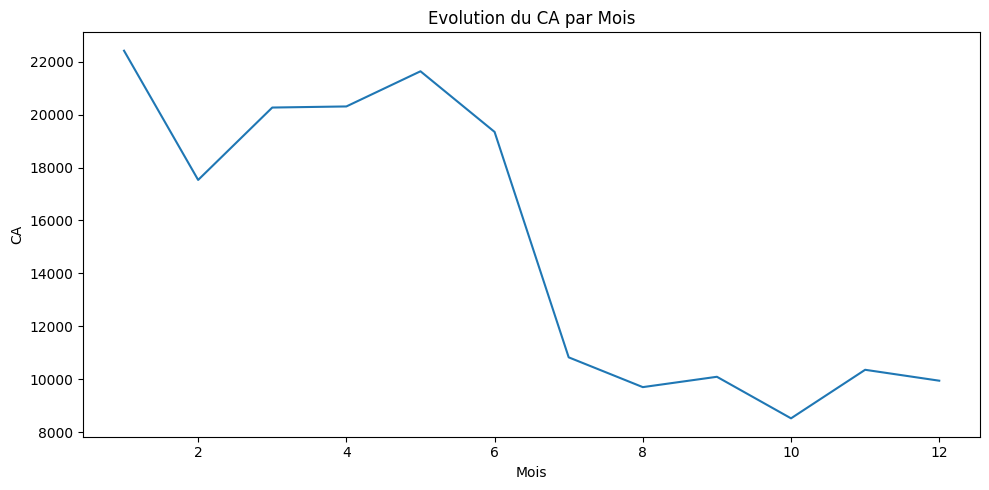

In [66]:
df.groupby('Mois')['Montant_Total'].sum().plot(kind = 'line',figsize = (10,5))
plt.title ('Evolution du CA par Mois')
plt.xlabel('Mois')
plt.ylabel('CA')
plt.tight_layout()
plt.show()

commentaire : Évolution du CA par mois (courbe décroissante, pic en janvier, creux en octobre)

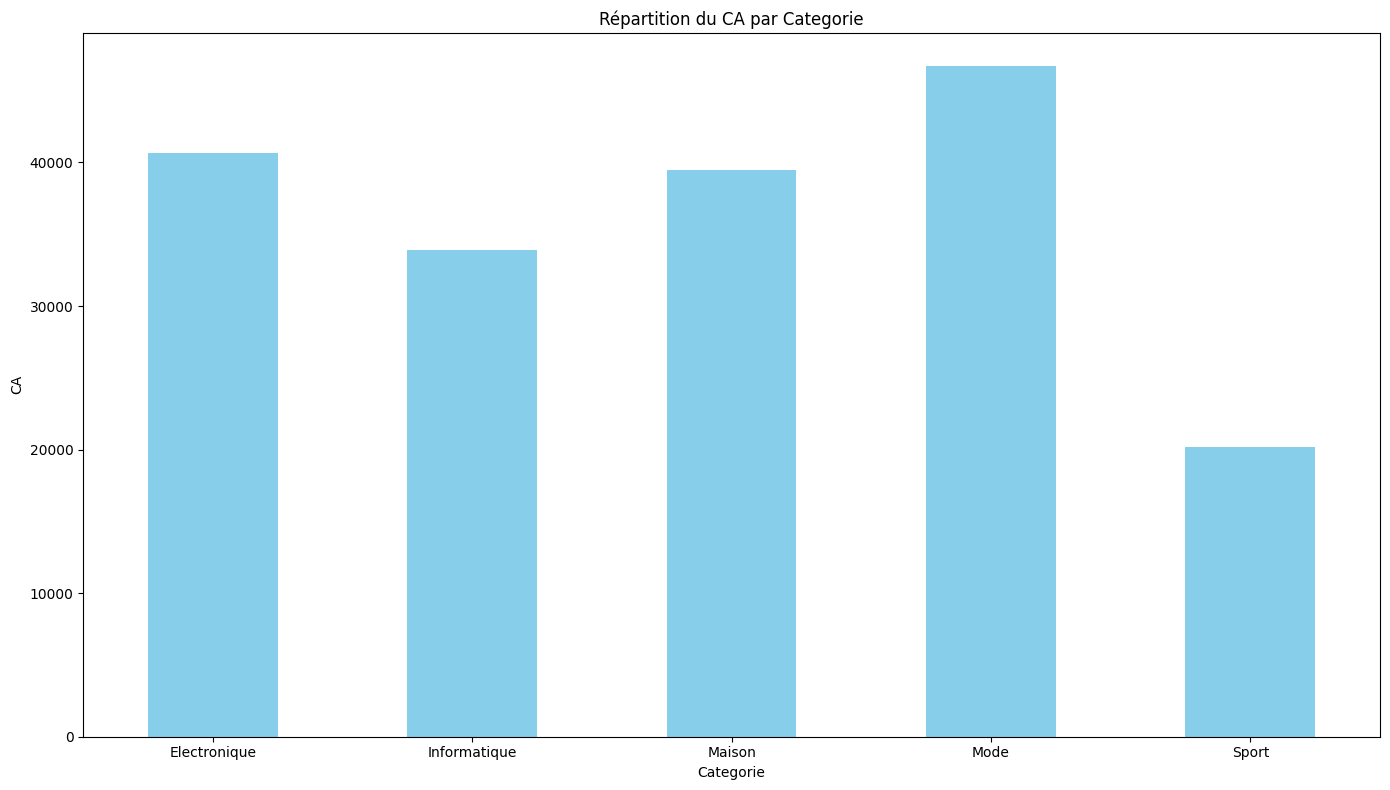

In [77]:
df.groupby('Categorie')['Montant_Total'].sum().plot(kind = 'bar',color = 'skyblue',figsize= (14,8))
plt.title ('Répartition du CA par Categorie')
plt.xlabel('Categorie')
plt.ylabel('CA')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

Commentaire : Répartition du CA par catégorie (barres : Mode et Électronique dominent)

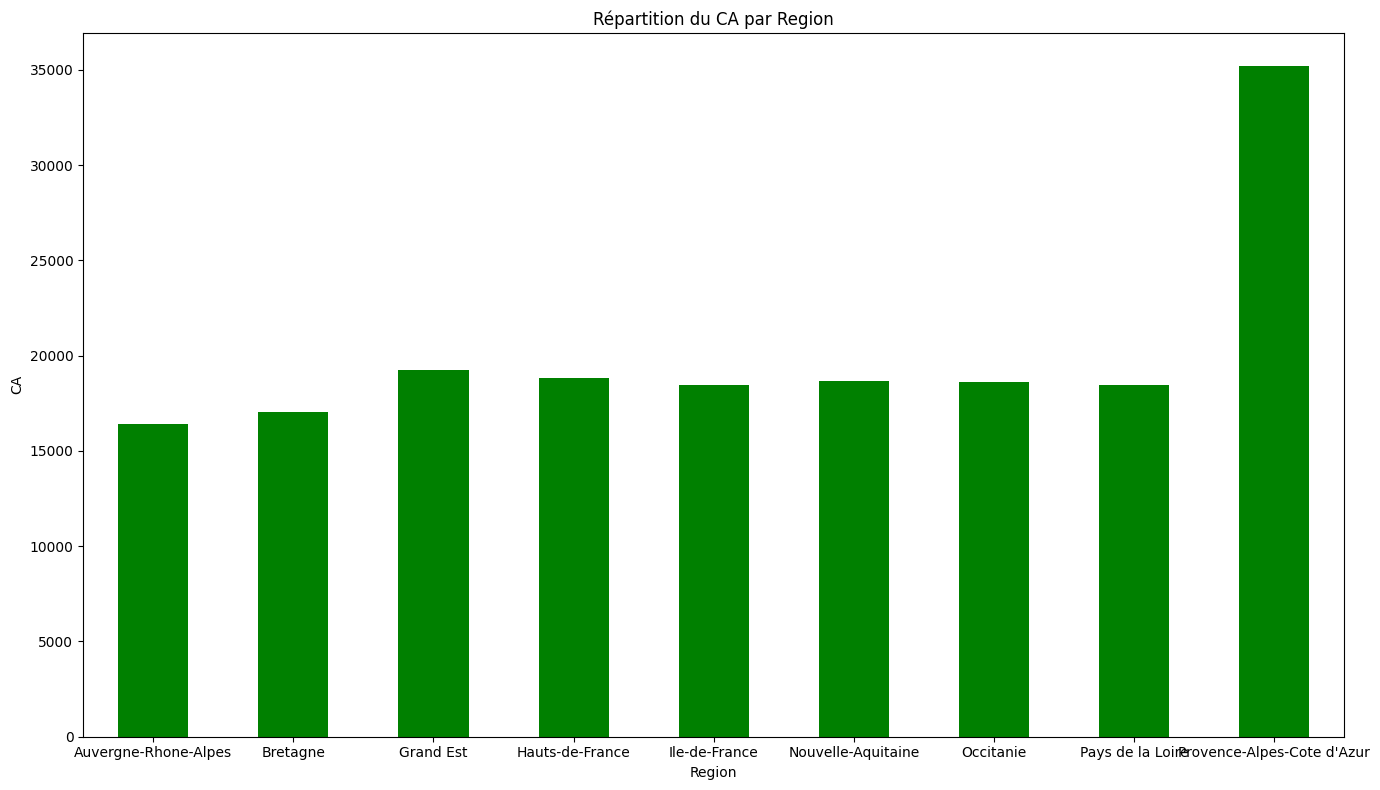

In [76]:
df.groupby('Region')['Montant_Total'].sum().plot(kind = 'bar',color = 'green',figsize= (14,8))
plt.title ('Répartition du CA par Region')
plt.xlabel('Region')
plt.ylabel('CA')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

Commentaire : Répartition du CA par région (barres : disparités fortes entre régions)

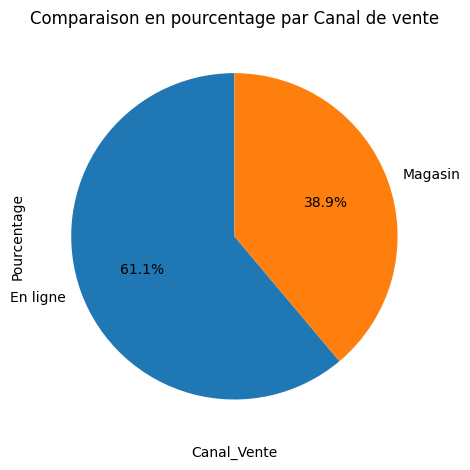

In [83]:
df.groupby('Canal_Vente')['Montant_Total'].sum().plot(kind = 'pie',autopct = '%1.1f%%',startangle = 90)
plt.title ('Comparaison en pourcentage par Canal de vente')
plt.xlabel('Canal_Vente')
plt.ylabel('Pourcentage')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

Commentaire : Comparaison en pourcentage par canal de vente (camembert : en ligne > magasin)

Conclusion :
La société EVAME dispose d’une base solide avec un chiffre d’affaires conséquent et des produits phares attractifs. Toutefois, la forte proportion de retours et d’annulations ainsi que la baisse progressive des ventes au fil des mois nécessitent une stratégie corrective. En mettant l’accent sur la qualité client, le renforcement du canal digital et une meilleure gestion régionale, EVAME peut améliorer sa rentabilité et stabiliser sa croissance.